In [1]:
import datetime
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
lib1 = 'EClibtest_RPTR1df.csv'
lib2 = 'EClibtest_RPTR2df.csv'
lib3 = 'EClibtest_ADdf.csv'

In [10]:
lib1df = pd.read_csv(lib1, index_col='Unnamed: 0')
lib2df = pd.read_csv(lib2, index_col='Unnamed: 0')
lib3df = pd.read_csv(lib3, index_col='Unnamed: 0')


In [17]:
lib1df

,index,BCs,TBB,Library,Putative_Tile,Putative_AD
2,CCTGACTGATAGGG,840,AGAGATAAACCATTGCCACCAATTGTTGTTGAAGATCCAAATGATA...,Staller_R1_MVS_0095_I1_TGCAGGCTAT,AGAGATAAACCATTGCCACCAATTGTTGTTGAAGATCCAAATGATA...,ACTAGCTTTTA
3,ATACCCTTCGCTAG,599,CAACCAATCTTGGATCCACAAACTGCTGCTGCTTACTTTAAGAATT...,Staller_R1_MVS_0095_I1_TGCAGGCTAT,CAACCAATCTTGGATCCACAAACTGCTGCTGCTTACTTTAAGAATT...,CTGCGCTAAGT
4,GAGGTGAAATGTTA,212,TCTAATAAGATTACTACTTTGGATTTGCCAGTTGTTACTACTGATT...,Staller_R1_MVS_0095_I1_TGCAGGCTAT,TCTAATAAGATTACTACTTTGGATTTGCCAGTTGTTACTACTGATT...,TCTACGCTTTC
5,GTCCTTTATTACAC,175,AATCAACAACCACCAGCTAAGATGGATTTGCAAGATGCATTCTCTT...,Staller_R1_MVS_0095_I1_TGCAGGCTAT,AATCAACAACCACCAGCTAAGATGGATTTGCAAGATGCATTCTCTT...,TGTACAGATGC
7,ATATAACCGAACTT,135,TCTCAACATAGATTGTCTACTCCATCTGTTCCACCAGTTCCATTGT...,Staller_R1_MVS_0095_I1_TGCAGGCTAT,TCTCAACATAGATTGTCTACTCCATCTGTTCCACCAGTTCCATTGT...,ATATATAATAA
...,...,...,...,...,...,...
80559,TCCTAGCCACAAAG,1,TTGTTTGATTTGCCATTGGACTTTGGTGCTGATGATGTTACTAAAG...,Staller_R1_MVS_0095_I1_TGCAGGCTAT,TTGTTTGATTTGCCATTGGACTTTGGTGCTGATGATGTTACTAAAG...,TTTACAGAGTT
80560,GTATCCTTAACGTG,1,TCTTCTTCATTCTCTTCTGCTTCTGCTAATATCTTGCCAAGAGACT...,Staller_R1_MVS_0095_I1_TGCAGGCTAT,TCTTCTTCATTCTCTTCTGCTTCTGCTAATATCTTGCCAAGAGACT...,AATGAGTCGTG
80561,GAGGTAAACCGGGG,1,TCTCAATCTACTTGGTTTCCATCTTCTACTCCATCTTTGCCAGCTT...,Staller_R1_MVS_0095_I1_TGCAGGCTAT,TCTCAATCTACTTGGTTTCCATCTTCTACTCCATCTTTGCCAGCTT...,AATAGACTTGA
80562,TGATTCGGGCGATC,1,TCTACTTCTTCTTTAAATTCTCCAGAATCTACTATTGCTACTACTG...,Staller_R1_MVS_0095_I1_TGCAGGCTAT,TCTACTTCTTCTTTAAATTCTCCAGAATCTACTATTGCTACTACTG...,CACTGTTGAAC


In [27]:
lib2df

,index,BCs,TBB,Library,Putative_Tile,Putative_AD
2,CCTGACTGATAGGG,706,AGAGATAAACCATTGCCACCAATTGTTGTTGAAGATCCAAATGATA...,Staller_R2_MVS_0094_I1_TGACGTCGTC,AGAGATAAACCATTGCCACCAATTGTTGTTGAAGATCCAAATGATA...,ACTAGCTTTTA
3,TTTAACGCATGAGT,326,CCATCTCAATTGCAGAATACTACTCCAAATTCTCCACAACCAACTA...,Staller_R2_MVS_0094_I1_TGACGTCGTC,CCATCTCAATTGCAGAATACTACTCCAAATTCTCCACAACCAACTA...,TTGCTCGCTCG
4,ATACCCTTCGCTAG,325,CAACCAATCTTGGATCCACAAACTGCTGCTGCTTACTTTAAGAATT...,Staller_R2_MVS_0094_I1_TGACGTCGTC,CAACCAATCTTGGATCCACAAACTGCTGCTGCTTACTTTAAGAATT...,CTGCGCTAAGT
5,GAGGTGAAATGTTA,238,TCTAATAAGATTACTACTTTGGATTTGCCAGTTGTTACTACTGATT...,Staller_R2_MVS_0094_I1_TGACGTCGTC,TCTAATAAGATTACTACTTTGGATTTGCCAGTTGTTACTACTGATT...,TCTACGCTTTC
6,ATATAACCGAACTT,223,TCTCAACATAGATTGTCTACTCCATCTGTTCCACCAGTTCCATTGT...,Staller_R2_MVS_0094_I1_TGACGTCGTC,TCTCAACATAGATTGTCTACTCCATCTGTTCCACCAGTTCCATTGT...,ATATATAATAA
...,...,...,...,...,...,...
84613,TATTAACAACGTAA,1,ATTGTTCCAGAATCTGGTGATCCAGCTGCTTTGAAGAGAGCTAGAA...,Staller_R2_MVS_0094_I1_TGACGTCGTC,ATTGTTCCAGAATCTGGTGATCCAGCTGCTTTGAAGAGAGCTAGAA...,GAACTATCAAA
84615,GATCAAATCACGCA,1,TCTGAACAATGGGATTCTTTGTTTCCAGCTAATGATCCATTCTCTG...,Staller_R2_MVS_0094_I1_TGACGTCGTC,TCTGAACAATGGGATTCTTTGTTTCCAGCTAATGATCCATTCTCTG...,CCCTTCGTGCT
84617,TCGTTTCAACTAAA,1,GAAGATTTGTCTGGTGCTTCTTCTGATGATTCTTCTAGAAGATCTT...,Staller_R2_MVS_0094_I1_TGACGTCGTC,GAAGATTTGTCTGGTGCTTCTTCTGATGATTCTTCTAGAAGATCTT...,AATGCACACTA
84618,CAAGCTTGCTACAT,1,GTTCCAGCTCCAGATACTTCTTCTAACTTTGTCTTTCCAAGATGTA...,Staller_R2_MVS_0094_I1_TGACGTCGTC,GTTCCAGCTCCAGATACTTCTTCTAACTTTGTCTTTCCAAGATGTA...,GACCCGGCGCT


In [33]:
lib12 = lib1df.merge(lib2df, how='outer', on='index')
lib12

,index,BCs_x,TBB_x,Library_x,Putative_Tile_x,Putative_AD_x,BCs_y,TBB_y,Library_y,Putative_Tile_y,Putative_AD_y
0,CCTGACTGATAGGG,840,AGAGATAAACCATTGCCACCAATTGTTGTTGAAGATCCAAATGATA...,Staller_R1_MVS_0095_I1_TGCAGGCTAT,AGAGATAAACCATTGCCACCAATTGTTGTTGAAGATCCAAATGATA...,ACTAGCTTTTA,706,AGAGATAAACCATTGCCACCAATTGTTGTTGAAGATCCAAATGATA...,Staller_R2_MVS_0094_I1_TGACGTCGTC,AGAGATAAACCATTGCCACCAATTGTTGTTGAAGATCCAAATGATA...,ACTAGCTTTTA
1,ATACCCTTCGCTAG,599,CAACCAATCTTGGATCCACAAACTGCTGCTGCTTACTTTAAGAATT...,Staller_R1_MVS_0095_I1_TGCAGGCTAT,CAACCAATCTTGGATCCACAAACTGCTGCTGCTTACTTTAAGAATT...,CTGCGCTAAGT,325,CAACCAATCTTGGATCCACAAACTGCTGCTGCTTACTTTAAGAATT...,Staller_R2_MVS_0094_I1_TGACGTCGTC,CAACCAATCTTGGATCCACAAACTGCTGCTGCTTACTTTAAGAATT...,CTGCGCTAAGT
2,GAGGTGAAATGTTA,212,TCTAATAAGATTACTACTTTGGATTTGCCAGTTGTTACTACTGATT...,Staller_R1_MVS_0095_I1_TGCAGGCTAT,TCTAATAAGATTACTACTTTGGATTTGCCAGTTGTTACTACTGATT...,TCTACGCTTTC,238,TCTAATAAGATTACTACTTTGGATTTGCCAGTTGTTACTACTGATT...,Staller_R2_MVS_0094_I1_TGACGTCGTC,TCTAATAAGATTACTACTTTGGATTTGCCAGTTGTTACTACTGATT...,TCTACGCTTTC
3,GTCCTTTATTACAC,175,AATCAACAACCACCAGCTAAGATGGATTTGCAAGATGCATTCTCTT...,Staller_R1_MVS_0095_I1_TGCAGGCTAT,AATCAACAACCACCAGCTAAGATGGATTTGCAAGATGCATTCTCTT...,TGTACAGATGC,80,AATCAACAACCACCAGCTAAGATGGATTTGCAAGATGCATTCTCTT...,Staller_R2_MVS_0094_I1_TGACGTCGTC,AATCAACAACCACCAGCTAAGATGGATTTGCAAGATGCATTCTCTT...,TGTACAGATGC
4,ATATAACCGAACTT,135,TCTCAACATAGATTGTCTACTCCATCTGTTCCACCAGTTCCATTGT...,Staller_R1_MVS_0095_I1_TGCAGGCTAT,TCTCAACATAGATTGTCTACTCCATCTGTTCCACCAGTTCCATTGT...,ATATATAATAA,223,TCTCAACATAGATTGTCTACTCCATCTGTTCCACCAGTTCCATTGT...,Staller_R2_MVS_0094_I1_TGACGTCGTC,TCTCAACATAGATTGTCTACTCCATCTGTTCCACCAGTTCCATTGT...,ATATATAATAA
...,...,...,...,...,...,...,...,...,...,...,...
27242,TATGTATTCGTTAC,1,CAACAACAACAACAACAACAACAATCTATCTTGTCTCCAACTACTG...,Staller_R1_MVS_0095_I1_TGCAGGCTAT,CAACAACAACAACAACAACAACAATCTATCTTGTCTCCAACTACTG...,GGTGAGGGACA,1,CAACAACAACAACAACAACAACAATCTATCTTGTCTCCAACTACTG...,Staller_R2_MVS_0094_I1_TGACGTCGTC,CAACAACAACAACAACAACAACAATCTATCTTGTCTCCAACTACTG...,GGTGAGGGACA
27243,TGTTTTTGGTGATT,1,GAAGCTCATGAAGTTGATTTGTTTGGTTTGCCATCTACTGACTTTC...,Staller_R1_MVS_0095_I1_TGCAGGCTAT,GAAGCTCATGAAGTTGATTTGTTTGGTTTGCCATCTACTGACTTTC...,GTAGAAAGGCC,2,GAAGCTCATGAAGTTGATTTGTTTGGTTTGCCATCTACTGACTTTC...,Staller_R2_MVS_0094_I1_TGACGTCGTC,GAAGCTCATGAAGTTGATTTGTTTGGTTTGCCATCTACTGACTTTC...,GTAGAAAGGCC
27244,ATCAATCAAGCAGT,1,TCTTGGTTCTCTTTGTTTCCAGATGCTAATCCATTGCCACAAGCTC...,Staller_R1_MVS_0095_I1_TGCAGGCTAT,TCTTGGTTCTCTTTGTTTCCAGATGCTAATCCATTGCCACAAGCTC...,GAGAACGTGAT,3,TCTTGGTTCTCTTTGTTTCCAGATGCTAATCCATTGCCACAAGCTC...,Staller_R2_MVS_0094_I1_TGACGTCGTC,TCTTGGTTCTCTTTGTTTCCAGATGCTAATCCATTGCCACAAGCTC...,GAGAACGTGAT
27245,TTGATAATATATGG,1,GAATTGTTGCAACAACCACATCAAGAAGCTTCTGCTTTGCACTTCT...,Staller_R1_MVS_0095_I1_TGCAGGCTAT,GAATTGTTGCAACAACCACATCAAGAAGCTTCTGCTTTGCACTTCT...,AGAGTAAGGAC,1,GAATTGTTGCAACAACCACATCAAGAAGCTTCTGCTTTGCACTTCT...,Staller_R2_MVS_0094_I1_TGACGTCGTC,GAATTGTTGCAACAACCACATCAAGAAGCTTCTGCTTTGCACTTCT...,AGAGTAAGGAC


In [34]:
lib12['BCs_x'].corr(lib12['BCs_y'])

0.872150966771193

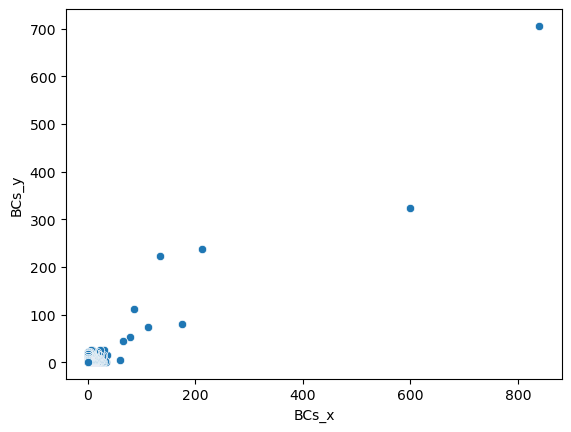

In [37]:
g = sns.scatterplot(data=lib12, x='BCs_x', y='BCs_y')
# g.set_yscale("log")
# g.set_xscale("log")

In [ ]:
lib12_outer = lib1df.merge(lib2df, how='outer', on='index')


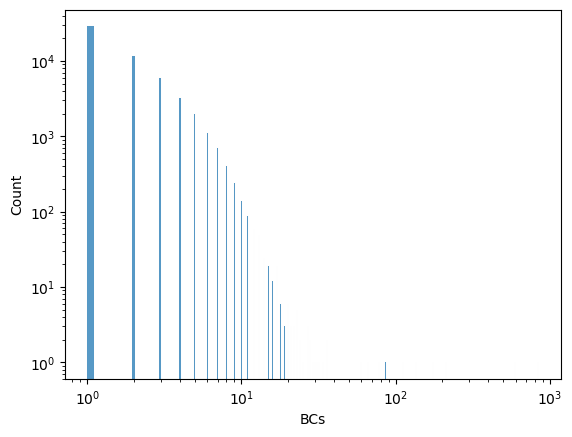

In [16]:
# plot distribution of BC coverage 
g = sns.histplot(data=lib1df, x='BCs')
g.set_yscale("log")
g.set_xscale("log")


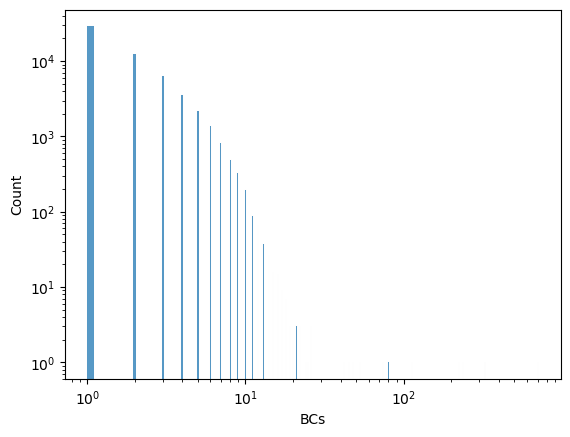

In [18]:
g = sns.histplot(data=lib2df, x='BCs')
g.set_yscale("log")
g.set_xscale("log")


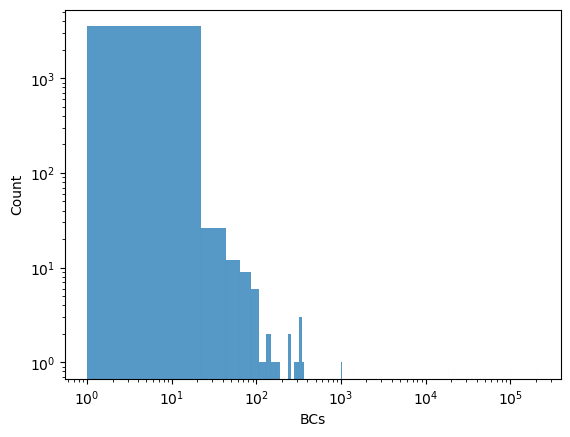

In [45]:
g = sns.histplot(data=lib3df, x='BCs', bins = 10000)
g.set_yscale("log")
g.set_xscale("log")


In [20]:
lib3df

,index,BCs,TBB,Library
0,TTACGCCAGGA,212994,0,Staller_TF_MVS_0096_I1_GAACAAGCGG
1,TGTAAGTTTCA,102582,ATGATGAATGCTGCTGGTTTGTGTACTAGAGATTTGACTTCTTCTA...,Staller_TF_MVS_0096_I1_GAACAAGCGG
2,AACCATTCTAG,21649,TATCATCCAGATAATGTTAATAATGATGAGAATTTGACTTTGGATT...,Staller_TF_MVS_0096_I1_GAACAAGCGG
3,TTTTAGTAACC,18952,0,Staller_TF_MVS_0096_I1_GAACAAGCGG
4,ACTTCTAAATA,1416,0,Staller_TF_MVS_0096_I1_GAACAAGCGG
...,...,...,...,...
3605,GGCCCACTTTG,1,0,Staller_TF_MVS_0096_I1_GAACAAGCGG
3606,AAGCTCTTGTT,1,0,Staller_TF_MVS_0096_I1_GAACAAGCGG
3607,ACCAGAATTAT,1,CATTCTAGATTGAAATTGACTTTGAGAGCTGATTTAAATTCTAATA...,Staller_TF_MVS_0096_I1_GAACAAGCGG
3608,TGGCTGGACCA,1,0,Staller_TF_MVS_0096_I1_GAACAAGCGG


In [25]:
lib3df_clean = lib3df.replace("0", np.nan)
lib3df_clean = lib3df_clean.dropna()
lib3df_clean

,index,BCs,TBB,Library
1,TGTAAGTTTCA,102582,ATGATGAATGCTGCTGGTTTGTGTACTAGAGATTTGACTTCTTCTA...,Staller_TF_MVS_0096_I1_GAACAAGCGG
2,AACCATTCTAG,21649,TATCATCCAGATAATGTTAATAATGATGAGAATTTGACTTTGGATT...,Staller_TF_MVS_0096_I1_GAACAAGCGG
17,TGTAAGTTACA,137,TTTATGTCTGCTCCAAATTCTTCTGCTTTGACTGCTTTGACTTCTC...,Staller_TF_MVS_0096_I1_GAACAAGCGG
36,CCATGTGCGGA,59,GACTTTGATGCTTTGTTTGATTTGACTGCTAATTCATTTGTTGATG...,Staller_TF_MVS_0096_I1_GAACAAGCGG
103,GTTTAGTAACC,11,GATGTTGAATTGGAAGAATTTACTGCATTTGAAGGTGGTGCTAATA...,Staller_TF_MVS_0096_I1_GAACAAGCGG
...,...,...,...,...
3597,CTCATGTTTCG,1,GGTGCTTCTGCTCAGAATGCTTCATTTCATTCTGCTTATTCTTCTC...,Staller_TF_MVS_0096_I1_GAACAAGCGG
3600,GGAAGCCACTT,1,GCTCCAATGATGTCTAGATATGATTCTTCTCCAGGTCAATCTTCTT...,Staller_TF_MVS_0096_I1_GAACAAGCGG
3602,AACCAGTGGCT,1,TATCCATTGTTTCCACCAGAAGAACAAATGTCTGCTCCACCTAAGA...,Staller_TF_MVS_0096_I1_GAACAAGCGG
3603,GCGGTCGACAC,1,AGATTTACTCCAGCTCAATCTCCACATCAATTCTATGCTTCTTCTG...,Staller_TF_MVS_0096_I1_GAACAAGCGG


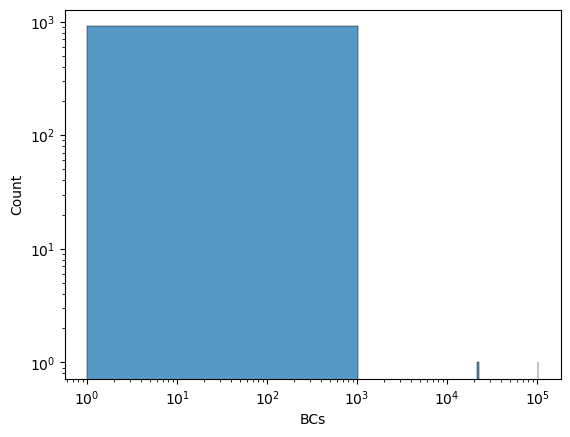

In [55]:
g = sns.histplot(data=lib3df_clean, x='BCs', bins=100)
g.set_yscale("log")
g.set_xscale("log")
